In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


# Setting up train_data, train_labels, and test_data

In [2]:
train_data = pd.read_csv("/kaggle/input/titanic/train.csv")
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
train_labels = pd.read_csv("/kaggle/input/titanic/train.csv")["Survived"]
train_labels.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [4]:
test_data = pd.read_csv("/kaggle/input/titanic/test.csv")
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


# EDA & stuff

In [5]:
train_data.info()

# missing info in age, cabin, & embarked

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
import matplotlib.pyplot as plt
corr_m = train_data.corr()
corr_m

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [7]:
corr_m["Survived"].sort_values(ascending = False)

Survived       1.000000
Fare           0.257307
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.077221
Pclass        -0.338481
Name: Survived, dtype: float64

array([[<AxesSubplot:title={'center':'Age'}>]], dtype=object)

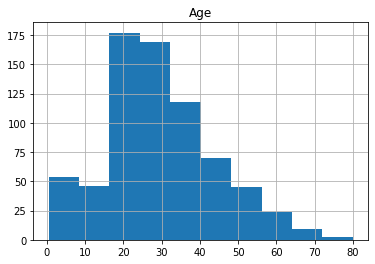

In [8]:
train_data.hist(column = "Age") # later, maybe use simple imputer with strategy as most_frequent or avg?

In [9]:
train_data["Age"].mean()

29.69911764705882

In [10]:
train_data["Age"].mode()

0    24.0
dtype: float64

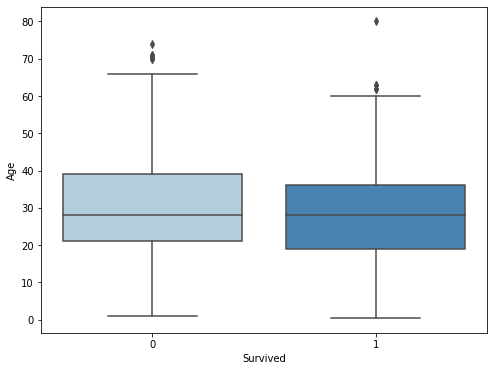

In [11]:
import seaborn as sns
plt.figure (figsize= (8,6))
sns.boxplot(x="Survived", y="Age", data=train_data, showfliers = True, palette = "Blues")
plt.show ()

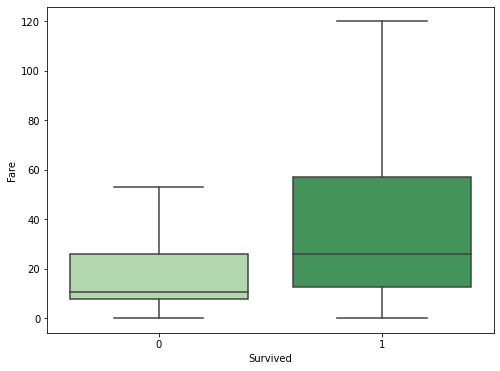

In [12]:
plt.figure (figsize= (8,6))
sns.boxplot(x="Survived", y="Fare", data=train_data, showfliers = False, palette = "Greens")
plt.show ()

I initially thought age would be a more significant factor in determining survival. However, it looks like fare has a higher importance, with higher fares (esp with fares that were at least at the ~30 mark) leading to a better chance of survival.

In [13]:
train_data["Cabin"].unique() 
# maybe separate the letters from numbers, then use onehot to convert letters to numerical data in pipeline
# use most_frequent strategy for missing data

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [14]:
train_data["Ticket"].head() 
# this seems annoying... drop

0           A/5 21171
1            PC 17599
2    STON/O2. 3101282
3              113803
4              373450
Name: Ticket, dtype: object

In [15]:
train_data["Embarked"].value_counts()
# C = Cherbourg, Q = Queenstown, S = Southampton
# use most_frequent strategy for missing data

S    644
C    168
Q     77
Name: Embarked, dtype: int64

# Drop it like it's  hot

In [16]:
train_data = train_data.drop("Survived", axis=1)

# Transformers (not megatron)

In [17]:
from sklearn.base import BaseEstimator, TransformerMixin

class CabinTransformer(TransformerMixin, BaseEstimator):
    def __init__(self):
        pass
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X_copy = X.copy()
        X_copy['Cabin letter'] = X_copy['Cabin'].str[0]
        return X_copy

In [18]:
class Remover(TransformerMixin, BaseEstimator):
    def __init__(self, yuck):
        self.yuck = yuck

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_copy = X.copy()

        X_copy = X_copy.drop(self.yuck, axis=1)

        return X_copy

In [19]:
class RareCabinTransformer(TransformerMixin, BaseEstimator):
    def __init__(self):
        pass
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_copy = X.copy()
        frequencies = X_copy['Cabin'].value_counts(normalize=True, ascending=True)
        X_copy['Cabin'] = X_copy['Cabin'].mask(X_copy['Cabin'].map(X_copy['Cabin'].value_counts(normalize=True)) < 0.1, 'Other')
        X_copy['Cabin']
        return X_copy

# Pipeline

In [20]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

In [21]:
yuck = ["Name", "PassengerId", "Ticket", "Cabin"]
cat_stuff = ["Cabin letter", "Embarked", "Sex"]
num_stuff = ["Age", "SibSp", "Parch", "Pclass", "Fare"]

num_pipeline = Pipeline ([
    ("imputer", SimpleImputer(strategy="mean")),
    ("std", StandardScaler())
])

cat_pipeline = Pipeline ([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("one_hot", OneHotEncoder())
])

core_pipeline = ColumnTransformer([
    ("cat", cat_pipeline, cat_stuff),
    ("num", num_pipeline, num_stuff)
])

full_pipeline = Pipeline ([
    ("rare_cabin", RareCabinTransformer()),
    ("cabin", CabinTransformer()),
    ("arrivederci", Remover(yuck)),
    ("core_pipeline", core_pipeline)
])

In [22]:
train_prepared = full_pipeline.fit_transform(train_data)
test_prepared = full_pipeline.fit_transform(test_data)

In [23]:
train_prepared.shape, train_labels.shape, test_prepared.shape

((891, 11), (891,), (418, 11))

# Model time yuh

In [24]:
from sklearn.model_selection import cross_val_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [25]:
model = [ KNeighborsClassifier(), DecisionTreeClassifier(random_state=42), SVC (random_state=42),
       RandomForestClassifier(random_state=42), GradientBoostingClassifier(random_state=42) ]
model_name = [ 'KNN', 'Decision Tree', 'SVM', 'Random Forest', 'Gradient Boosting' ]

for model, model_name in zip(model,model_name):
  model.fit ( train_prepared, train_labels)
  y_pred = model.predict ( train_prepared )
  print ( f'{model_name}: %.3f \n' %cross_val_score (model, train_prepared, train_labels, cv=8).mean() )

KNN: 0.806 

Decision Tree: 0.785 

SVM: 0.826 

Random Forest: 0.813 

Gradient Boosting: 0.838 



Gradient boosting looks like it could be our best bet!

## Tuning time

In [26]:
from sklearn.model_selection import GridSearchCV

gboost = GradientBoostingClassifier()

param_grid = { 
    'n_estimators': [10, 50, 100, 200, 500],
    "max_depth":[1, 3, 5, 7, 9],
    "learning_rate":[0.01, 0.1, 0.5, 1,10]
}

grid_search = GridSearchCV (estimator = gboost,
                   param_grid = param_grid,
                   scoring = 'accuracy',
                   cv = 5,
                   n_jobs = -1,
                   )

grid_search = grid_search.fit (train_prepared, train_labels)

In [27]:
grid_search.best_params_

{'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 500}

In [28]:
grid_search.best_score_

0.8305442219571904

# Evaluation

In [29]:
grid_search = grid_search.best_estimator_

grid_search.fit(train_prepared, train_labels)
print(f'Train score: %.4f' %grid_search.score (train_prepared, train_labels))

Train score: 0.9259


# Prediction

In [30]:
new_predict = grid_search.predict(test_prepared)
new_predict

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [31]:
predictions = pd.DataFrame(np.arange(1,419).reshape(418,1))
predictions['Survived'] = pd.Series(new_predict)

predictions = predictions.drop([0], axis=1)

In [32]:
predictions['PassengerId'] = test_data["PassengerId"]

predictions = predictions.reindex(columns=['PassengerId', 'Survived'])

predictions

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [33]:
predictions.to_csv(r'titanic_results.csv', index = False)